In [1]:
# import libraries here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# for ROC curve and area calculation (AUC )
from sklearn.metrics import roc_curve, auc

# for precision recall curve and area calculation
from sklearn.metrics import precision_recall_curve, average_precision_score

# for balanced accuracy calculation
from sklearn.metrics import balanced_accuracy_score


In [2]:
# define functions here
# todo: check whether used or not, delete those not used

def cal_accuracy(X, y):
         
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1, stratify = y)
    
    # Define and train the model
    model = RandomForestClassifier(random_state=1)
    model.fit(X_train, y_train.values.ravel())
    
    # Make predictions on the test set
    # y_pred = model.predict(X_test)
    
    # Create confusion matrix using only test set predictions
    # cm = confusion_matrix(y_test, y_pred)
        
    # Calculate accuracy
    accuracy = model.score(X_test, y_test)
    return accuracy

# define the function
def cal_balanced_accuracy(X, y):
         
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1, stratify = y)
    
    # Define and train the model
    model = RandomForestClassifier(random_state=1)
    model.fit(X_train, y_train.values.ravel())
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    # Create confusion matrix using only test set predictions
    # cm = confusion_matrix(y_test, y_pred)
        
    # Calculate accuracy
    accuracy = model.score(X_test, y_test)
    balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
    
    return balanced_accuracy

# define the function
def cal_ROC_curve(X, y, title_str = 'ROC Curve for Random Forest Classifier',save_fig = False, fig_name = "figure_plot"):
         
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1, stratify = y)
    
    # Define and train the model
    model = RandomForestClassifier(random_state=1)
    model.fit(X_train, y_train.values.ravel())
        
    # Predict probabilities for the positive class
    y_score = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
        
    plt.figure(figsize=(200/72, 200/72))  # 300x100 pts
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title_str)
    plt.legend(loc='lower right', fontsize=8)
    if save_fig:
        save_and_download(fig_name, download=True, formats=['pdf'])
    plt.show()
    return roc_auc

# define the function
def cal_PRC_curve(X, y, save_fig = False, fig_name = "figure_plot"):
         
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1, stratify = y)
    
    # Define and train the model
    model = RandomForestClassifier(random_state=2)
    model.fit(X_train, y_train.values.ravel())
        
    # Predict probabilities for the positive class
    y_scores = model.predict_proba(X_test)[:, 1]

    # Compute precision and recall at various thresholds
    precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

    # (Optional) Compute average precision (area under PR curve)
    avg_precision = average_precision_score(y_test, y_scores)

    baseline = np.mean(y_test)

    # Plot the PR curve
    plt.figure(figsize=(200/72, 200/72))  # 300x100 pts
    plt.plot(recall, precision, label=f'PR curve (AP = {avg_precision:.2f})')
    plt.hlines(baseline, 0, 1, linestyle='--', label=f'Baseline (precision={baseline:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision–Recall Curve')
    plt.legend(loc='lower right', fontsize=8)
    if save_fig:
        save_and_download(fig_name, download=True, formats=['pdf'])
    #plt.grid(True)
    plt.show()
    return avg_precision

# Bar Plot
def plot_bar(bar_data, with_labels = False, save_fig = False, fig_name = "figure_plot"):
    if with_labels:
        plt.figure(figsize=(8, 6))
        num_classes = len(bar_data)
        colors = sns.color_palette("Blues_r", n_colors=1)

        bars = plt.bar(range(num_classes), bar_data, color=colors)
        # plt.axhline(y=0.62, color='red', linestyle='--', linewidth=2, label="random classification 0.64")

        # plt.title("accuracy")
        plt.xlabel("Predicted Ligand")
        plt.ylabel("Accuracy")
        plt.ylim(0, 1)
        plt.xticks(range(num_classes), [label_accuracy[i] for i in range(num_classes)], rotation=45, ha='right')
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.2f}', ha='center', va='bottom', fontsize=8)

    else:
        plt.figure(figsize=(200/72, 100/72))  # 300x100 pts
        plt.bar(range(len(bar_data)), bar_data, color=sns.color_palette("Blues_r", n_colors=1))
        plt.ylim(0, 1)
        plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xticks(range(len(bar_data)))  # Set tick locations
        plt.gca().set_xticklabels([])  # Remove tick labels
   
    if save_fig:
        save_and_download(fig_name, download=True, formats=['pdf'])
    plt.show()

auto_download = 0
def save_and_download(filename, download=False, formats=None):
    """Saves the current figure in specified formats and optionally downloads it."""
    if formats is None:
        formats = ['pdf']  # Default format if none specified

    for fmt in formats:
        plt.savefig(f"{filename}.{fmt}", bbox_inches='tight', dpi=300)
        if download and auto_download:
            try:
                from google.colab import files
                files.download(f"{filename}.{fmt}")
            except ImportError:
                print("Not running in Colab environment.  Download skipped.")


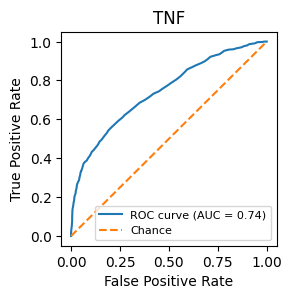

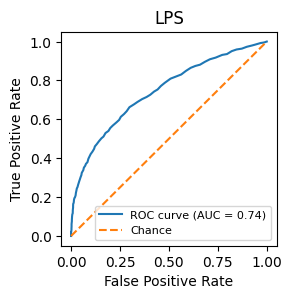

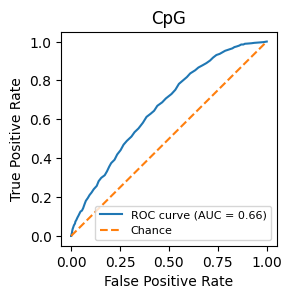

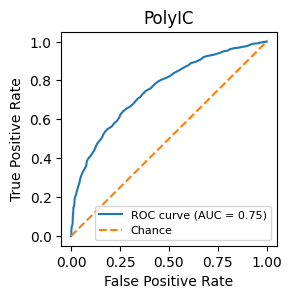

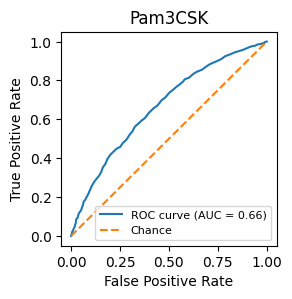

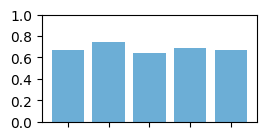

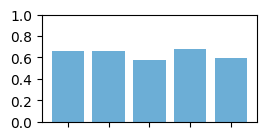

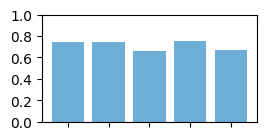

[0.66138408 0.65722444 0.57445764 0.67645496 0.59521913]
[0.74110549 0.74189754 0.66247809 0.75457878 0.66462329]


In [3]:
# experimental data: SRS

debug_or_not = 0

# Load the data
X0 = pd.read_csv('Comb_ligands_exp_conditions_X_codon_.csv', header=None)
y0 = pd.read_csv('Comb_ligands_exp_conditions_y_codon_.csv', header=None)

# remove single, and 5-combinatorial ones
# Define values to be removed
values_to_remove = {0, 1, 2, 3, 4, 30}

# Get mask for rows where y is NOT in values_to_remove
mask = ~y0[0].isin(values_to_remove)

# Apply mask to X and y
X_filtered = X0[mask].reset_index(drop=True)  # Reset index after filtering
y_filtered = y0[mask].reset_index(drop=True)

# For debug Print shapes to verify
if debug_or_not: 
    print("Original X shape:", X0.shape, "Filtered X shape:", X_filtered.shape)
    print("Original y shape:", y0.shape, "Filtered y shape:", y_filtered.shape)
 
X = X_filtered
y = y_filtered


# calculate AUC for ROC

# Initialize an array to store accuracy AUC, label, indexs for each stimuli
acc_vec_pres_or_not = np.zeros(5)  
bal_acc_vec_pres_or_not = np.zeros(5)
AUC_vec = np.zeros(5)
label_accuracy = { 0: 'TNF',  1: 'LPS', 2: 'CpG', 3: 'PolyIC', 4: 'Pam3CSK'}
values_map = {
    1: {5, 6, 7, 8, 15, 16, 17, 18, 19,20,25,26,27,28},
    2: { 5, 9, 10, 11, 15, 16, 17, 21,22,23,25,26,27,29},
    3: { 6, 9, 12, 13, 15, 18, 19, 21,22,24,25,26,28,29},
    4: {7, 10, 12, 14, 16, 18, 20,21,23,24,25,27,28,29},
    5: {8, 11, 13, 14, 17, 19, 20,22,23,24,26,27,28,29},
}
ligand_labels = {
    1: "TNF",
    2: "LPS",
    3: "CpG",
    4: "PolyIC",
    5: "Pam3CSK"
}

# Loop through each case
for i_case, ligand_label in ligand_labels.items():
    # Define label mapping
    label_mapping = {
        0: f"no-{ligand_label}",
        1: ligand_label
    }

    # Define the values to be reassigned to 1
    values_to_set_1 = values_map[i_case]

    # Reassign values in y & calculate accuracy
    y = y0[mask].reset_index(drop=True)
    y[0] = y[0].apply(lambda val: 1 if val in values_to_set_1 else 0)

    acc_vec_pres_or_not[i_case - 1] = cal_accuracy(X, y)
    bal_acc_vec_pres_or_not[i_case - 1] = cal_balanced_accuracy(X, y)
    AUC_vec[i_case - 1] = cal_ROC_curve(X, y, ligand_label,False, "ROC_AUC"+ligand_label)

    # Debugging/monitoring
    if debug_or_not: 
        print(f"Case {i_case} - Ligand: {ligand_label}")
        print("sum of y after reassign:", np.sum(y))
        print("y shape:", y.shape)
        print("-" * 40)


# plot and save bar plot
if 1:
    plot_bar(acc_vec_pres_or_not,False, True,"exp_acc_barplot")
    plot_bar(bal_acc_vec_pres_or_not,False,True,"exp_bal_acc_barplot")
    plot_bar(AUC_vec,False,True,"exp_ROC_AUC_barplot")

print(bal_acc_vec_pres_or_not)
print(AUC_vec)

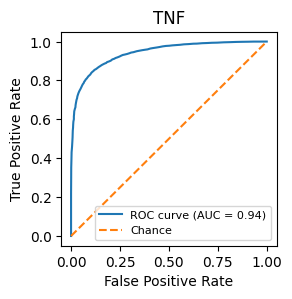

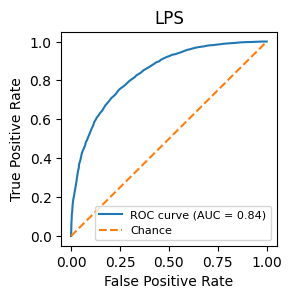

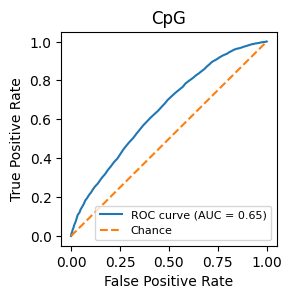

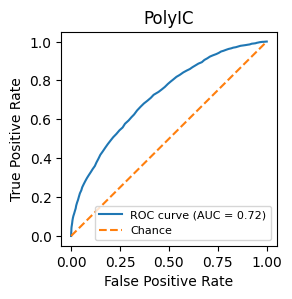

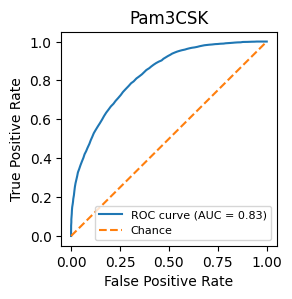

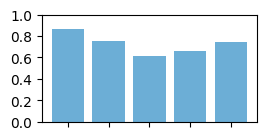

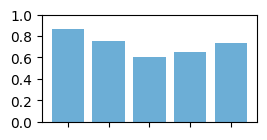

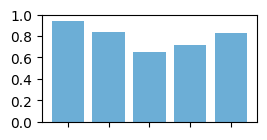

[0.8639526  0.74977734 0.60298581 0.65209629 0.73648346]
[0.94088222 0.83763553 0.64858138 0.71895297 0.82760601]


In [4]:
# model data: SRS

debug_or_not = 0

# Load the data
X0 = pd.read_csv('Comb_ligands_31conditions_X_codon_202604.csv', header=None)
y0 = pd.read_csv('Comb_ligands_31conditions_y_codon_202604.csv', header=None)

# remove single, and 5-combinatorial ones
# Define values to be removed
values_to_remove = {0, 1, 2, 3, 4, 30}

# Get mask for rows where y is NOT in values_to_remove
mask = ~y0[0].isin(values_to_remove)

# Apply mask to X and y
X_filtered = X0[mask].reset_index(drop=True)  # Reset index after filtering
y_filtered = y0[mask].reset_index(drop=True)

# For debug Print shapes to verify
if debug_or_not: 
    print("Original X shape:", X0.shape, "Filtered X shape:", X_filtered.shape)
    print("Original y shape:", y0.shape, "Filtered y shape:", y_filtered.shape)
 
X = X_filtered
y = y_filtered


# calculate AUC for ROC

# Initialize an array to store accuracy AUC, label, indexs for each stimuli
acc_vec_pres_or_not = np.zeros(5)  
bal_acc_vec_pres_or_not = np.zeros(5)
AUC_vec = np.zeros(5)
label_accuracy = { 0: 'TNF',  1: 'LPS', 2: 'CpG', 3: 'PolyIC', 4: 'Pam3CSK'}
values_map = {
    1: {5, 6, 7, 8, 15, 16, 17, 18, 19,20,25,26,27,28},
    2: { 5, 9, 10, 11, 15, 16, 17, 21,22,23,25,26,27,29},
    3: { 6, 9, 12, 13, 15, 18, 19, 21,22,24,25,26,28,29},
    4: {7, 10, 12, 14, 16, 18, 20,21,23,24,25,27,28,29},
    5: {8, 11, 13, 14, 17, 19, 20,22,23,24,26,27,28,29},
}
ligand_labels = {
    1: "TNF",
    2: "LPS",
    3: "CpG",
    4: "PolyIC",
    5: "Pam3CSK"
}

# Loop through each case
for i_case, ligand_label in ligand_labels.items():
    # Define label mapping
    label_mapping = {
        0: f"no-{ligand_label}",
        1: ligand_label
    }

    # Define the values to be reassigned to 1
    values_to_set_1 = values_map[i_case]

    # Reassign values in y & calculate accuracy
    y = y0[mask].reset_index(drop=True)
    y[0] = y[0].apply(lambda val: 1 if val in values_to_set_1 else 0)

    acc_vec_pres_or_not[i_case - 1] = cal_accuracy(X, y)
    bal_acc_vec_pres_or_not[i_case - 1] = cal_balanced_accuracy(X, y)
    AUC_vec[i_case - 1] = cal_ROC_curve(X, y, ligand_label,True, "ROC_AUC_sim_"+ligand_label)

    # Debugging/monitoring
    if debug_or_not: 
        print(f"Case {i_case} - Ligand: {ligand_label}")
        print("sum of y after reassign:", np.sum(y))
        print("y shape:", y.shape)
        print("-" * 40)


# plot and save bar plot
if 1:
    plot_bar(acc_vec_pres_or_not,False, True,"sim_acc_barplot")
    plot_bar(bal_acc_vec_pres_or_not,False,True,"sim_bal_acc_barplot")
    plot_bar(AUC_vec,False,True,"sim_ROC_AUC_barplot")
print(bal_acc_vec_pres_or_not)
print(AUC_vec)

In [5]:
auto_download = 0

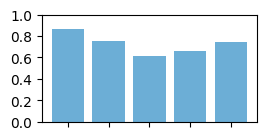

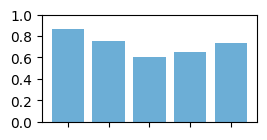

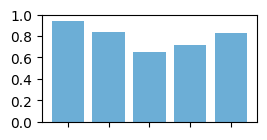

[0.8639526  0.74977734 0.60298581 0.65209629 0.73648346]
[0.94088222 0.83763553 0.64858138 0.71895297 0.82760601]


In [6]:
if 1:
    plot_bar(acc_vec_pres_or_not,False, True,"sim_acc_barplot")
    plot_bar(bal_acc_vec_pres_or_not,False,True,"sim_bal_acc_barplot")
    plot_bar(AUC_vec,False,True,"sim_ROC_AUC_barplot")
print(bal_acc_vec_pres_or_not)
print(AUC_vec)
